![截圖 2025-09-26 晚上10.44.32.png](<attachment:截圖 2025-09-26 晚上10.44.32.png>)
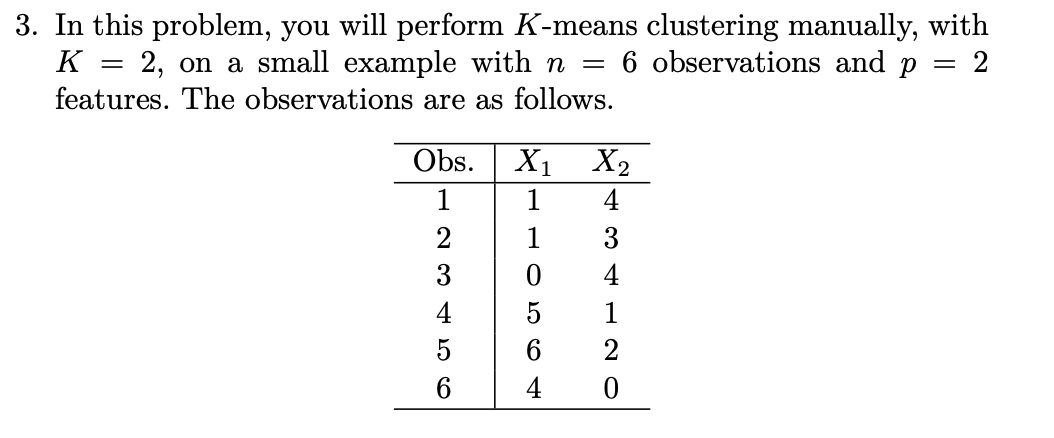

(a) Plot the observations.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

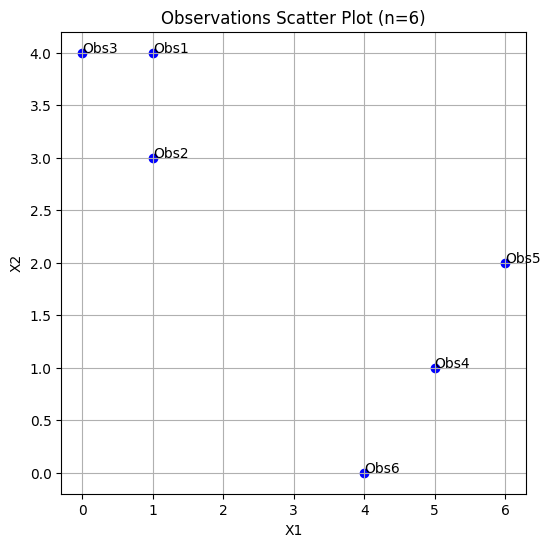

In [5]:
# 資料
X1 = [1, 1, 0, 5, 6, 4]
X2 = [4, 3, 4, 1, 2, 0]
labels = ['Obs1','Obs2','Obs3','Obs4','Obs5','Obs6']

plt.figure(figsize=(6, 6))
plt.scatter(X1, X2, c='blue')

# 在每個點旁邊標註觀測值編號
for i, label in enumerate(labels):
    plt.text(X1[i] , X2[i] , label)
    # plt.text(X1[i]+0.1 , X2[i]+0.1 , label)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Observations Scatter Plot (n=6)")
plt.grid(True)
plt.show()


(b) Randomly assign a cluster label to each observation. You can use
the np.random.choice() function to do this. Report the cluster
labels for each observation.

In [17]:
# Number of clusters (K = 2)
K = 2

# Randomly assign cluster labels
cluster_labels = np.random.choice(K, len(labels))


cluster_labels # array([1, 0, 1, 0, 1, 1])

# Report the cluster labels for each observation
for i in range(len(labels)):
    print(f'{labels[i]} Cluster: {cluster_labels[i]}')

Obs1 Cluster: 1
Obs2 Cluster: 1
Obs3 Cluster: 1
Obs4 Cluster: 1
Obs5 Cluster: 0
Obs6 Cluster: 0


(c) Compute the centroid for each cluster.

In [44]:
# 計算平均（centroid）計算平均（centroid）
# Before
# X1 = [1, 1, 0, 5, 6, 4]
# X2 = [4, 3, 4, 1, 2, 0]
# labels = ['Obs1','Obs2','Obs3','Obs4','Obs5','Obs6']
observation = np.column_stack((X1,X2))
observation
# After
# array([[1, 4],
#        [1, 3],
#        [0, 4],
#        [5, 1],
#        [6, 2],
#        [4, 0]])

# 已經分群
cluster_labels # array([1, 0, 1, 0, 1, 1])

# 找出每個分群的點
cluster0_point = observation[cluster_labels==0]
# [[6 2]
#  [4 0]]

cluster1_point = observation[cluster_labels==1]
# [[1 4]
#  [1 3]
#  [0 4]
#  [5 1]]

centroid0 = cluster0_point.mean(axis=0)  
centroid0 # [5., 1.]
# [[6 2]
#  [4 0]] 兩點找中心點
centroid1 = cluster1_point.mean(axis=0)  
centroid1 # [1.75, 3.  ]
# [[1 4]
#  [1 3]
#  [0 4]
#  [5 1]] 四點找中心點

# centroid_0 = np.mean(cluster0_point, axis=0) if len(cluster0_point) > 0 else None
# centroid_1 = np.mean(cluster1_point, axis=0) if len(cluster1_point) > 0 else None

print(f"Centroid of Cluster 0: {centroid0}")
print(f"Centroid of Cluster 1: {centroid1}")


Centroid of Cluster 0: [5. 1.]
Centroid of Cluster 1: [1.75 3.  ]


(d) Assign each observation to the centroid to which it is closest, in
terms of Euclidean distance. Report the cluster labels for each
observation.

new_cluster_labels = np.zeros(len(x1), dtype=int)</br>
</br>
for i in range(len(x1)):</br>
    distances = np.sqrt((x1[i] - centroids[:, 0]) ** 2 + (x2[i] - centroids[:, 1]) ** 2)</br>
    new_cluster_labels[i] = np.argmin(distances)</br>


In [62]:
def euclidean_distance(X1, Y1, X2, Y2):
    return np.sqrt((X1-X2)**2 + (Y1-Y2)**2)

new_cluster_list = []
for obs in observation:
    d1 = euclidean_distance(obs[0],obs[1],centroid0[0],centroid0[1])
    d2 = euclidean_distance(obs[0],obs[1],centroid1[0],centroid1[1])
    new_cluster_list.append( 0 if d1<d2 else 1)

# new_cluster_list
for i in range(len(labels)):
    print(f'{labels[i]} Cluster: {new_cluster_list[i]}')

Obs1 Cluster: 1
Obs2 Cluster: 1
Obs3 Cluster: 1
Obs4 Cluster: 0
Obs5 Cluster: 0
Obs6 Cluster: 0


(e) Repeat (c) and (d) until the answers obtained stop changing.

K-means 演算法</br>
1.初始化群標籤：隨機分配每個點的群</br>
2.計算每群的中心點 (centroid)：用目前的標籤算平均</br>
3.重新分配群標籤：每個點都分到距離最近的群</br>
4.重複步驟 2 & 3 : 直到標籤不再變動（收斂）


In [66]:
# 初始化標籤
cluster_labels = np.random.choice([0, 1], size=len(observation))

prev_labels = np.array([])

while not np.array_equal(prev_labels, cluster_labels):
    prev_labels = cluster_labels.copy()

    cluster_0 = observation[cluster_labels == 0]
    cluster_1 = observation[cluster_labels == 1]

    centroid_0 = cluster_0.mean(axis=0)
    centroid_1 = cluster_1.mean(axis=0)

    # 用向量化計算每個點到兩個 centroid 的距離
    new_labels = []
    for obs in observation:
        d0 = euclidean_distance(obs[0],obs[1],centroid0[0],centroid0[1])
        d1 = euclidean_distance(obs[0],obs[1],centroid1[0],centroid1[1])
        new_labels.append(0 if d0 < d1 else 1)
    cluster_labels = np.array(new_labels)

print(f"Final Labels: {cluster_labels}")
print(f"Centroid 0: {centroid_0}, Centroid 1: {centroid_1}")
final_cluster = cluster_labels

Final Labels: [1 1 1 0 0 0]
Centroid 0: [5. 1.], Centroid 1: [0.66666667 3.66666667]


(f) In your plot from (a), color the observations according to the
cluster labels obtained.

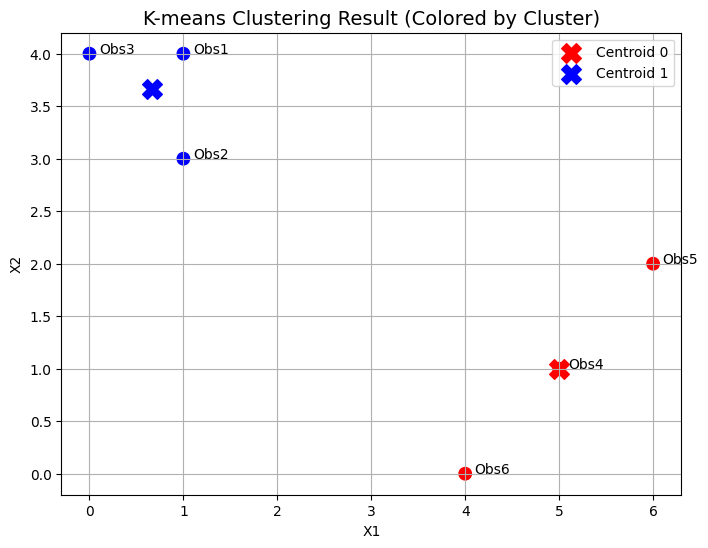

In [69]:
# 5. 畫圖（用顏色區分群）
colors = ['red' if label == 0 else 'blue' for label in final_cluster]

plt.figure(figsize=(8, 6))
plt.scatter(observation[:, 0], observation[:, 1], c=colors, s=80)

# 標註每個點的名字
for i, (x, y) in enumerate(observation):
    plt.text(x + 0.1, y, f'Obs{i+1}', fontsize=10)

# 標出 centroid，用 "X" 標記
plt.scatter(centroid_0[0], centroid_0[1], c='red', marker='X', s=200, label='Centroid 0')
plt.scatter(centroid_1[0], centroid_1[1], c='blue', marker='X', s=200, label='Centroid 1')

plt.title('K-means Clustering Result (Colored by Cluster)', fontsize=14)
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.legend()
plt.show()